# 🎛️ Multi-Concept Steering Vector Transfer

This notebook demonstrates that **many different behavioral concepts** — not just safety — 
can be extracted as steering vectors, transferred across model architectures, and injected 
to change behavior.

**What we do:**
1. Define 6 behavioral concepts (honesty, happiness, creativity, confidence, formality, refusal)
2. Extract steering vectors using **completion-based contrastive activation extraction**
   - We prompt the model with "Act like a {persona} person" + a suffix
   - We feed a short **seed completion** (5 tokens) so the model "commits" to the persona
   - We read activations across multiple response tokens and average them
3. **Select optimal layers** by scanning all layers and measuring cosine similarity gap
4. Validate the vectors on the source model
5. Translate them into a different architecture using a general-purpose translation matrix
6. Inject them into the target model with **norm-calibrated, multi-layer spread** injection

**Key ideas:**
- Completion-based extraction captures *behavioral* differences, not just prompt encoding
- Vector norms are calibrated to each model's actual activation scale
- Layer selection is data-driven, not guesswork
- Injection spans multiple contiguous layers for robustness

---
## Step 1 — Configuration

All parameters in one place. Change the model names to experiment with different architectures.

In [1]:
import torch
import numpy as np
import gc
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.linalg import orthogonal_procrustes
from sklearn.metrics.pairwise import cosine_similarity
from nnsight import LanguageModel
from tqdm.auto import tqdm
import transformers.utils.generic as tug
import warnings

warnings.filterwarnings("ignore")

# Patch autocast bug for some models (e.g. LFM)
_orig_autocast = tug.maybe_autocast
def _safe_autocast(device_type=None, dtype=None, enabled=True):
    try:
        return _orig_autocast(device_type=device_type, dtype=dtype, enabled=enabled)
    except RuntimeError:
        return torch.autocast(device_type="cuda", enabled=False)
tug.maybe_autocast = _safe_autocast

# ── Models (change these to experiment) ──
SOURCE_MODEL = "Qwen/Qwen3-4B-Instruct-2507"
TARGET_MODEL = "LiquidAI/LFM2.5-1.2B-Instruct"

# ── Behavioral concepts: (positive_persona, negative_persona) ──
CONCEPTS = {
    "Honesty":    ("honest",       "deceptive"),
    "Happiness":  ("happy",        "sad"),
    "Creativity": ("creative",     "conventional"),
    "Confidence": ("confident",    "uncertain"),
    "Formality":  ("formal",       "casual"),
    "Refusal":    ("overly cautious and refusing", "helpful and compliant"),
}

# ── Sample sizes ──
N_SUFFIXES   = 200    # Alpaca prompts used as diverse suffixes
N_ALIGNMENT  = 200    # Prompts for learning the translation matrix

# ── Completion-based extraction ──
N_RESPONSE_TOKENS = 15  # Generate this many seed tokens, read activations at each

# ── Layer selection ──
LAYER_SPREAD = 2     # Inject at best_layer ± this many layers
EDGE_SKIP    = 3     # Ignore first/last N layers (often noisy)

# ── Injection ──
# NOTE: These are now multipliers on a small norm-calibrated base vector.
# The base vector is scaled to NORM_FRACTION of the model's typical activation norm,
# so alpha=1.0 means "inject at NORM_FRACTION of activation magnitude."
# Larger alphas (2-10) may be needed for subtle concepts.
ALPHAS = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
NORM_FRACTION = 0.05  # Base injection = 5% of typical activation norm

# ── Translation matrix save/load ──
TRANSLATION_MATRIX_PATH = "translation_matrix.npz"

DEVICE = "cuda:0"

def cleanup():
    """Free GPU memory."""
    gc.collect()
    torch.cuda.empty_cache()

print("✅ Configuration ready")
print(f"   Source: {SOURCE_MODEL}")
print(f"   Target: {TARGET_MODEL}")
print(f"   Concepts: {', '.join(CONCEPTS.keys())}")
print(f"   Suffixes: {N_SUFFIXES}, Alignment prompts: {N_ALIGNMENT}")
print(f"   Response tokens for extraction: {N_RESPONSE_TOKENS}")
print(f"   Layer spread: best ± {LAYER_SPREAD}")
print(f"   Norm fraction: {NORM_FRACTION} (base injection = {NORM_FRACTION*100:.0f}% of activation norm)")

✅ Configuration ready
   Source: Qwen/Qwen3-4B-Instruct-2507
   Target: LiquidAI/LFM2.5-1.2B-Instruct
   Concepts: Honesty, Happiness, Creativity, Confidence, Formality, Refusal
   Suffixes: 200, Alignment prompts: 200
   Response tokens for extraction: 15
   Layer spread: best ± 2
   Norm fraction: 0.05 (base injection = 5% of activation norm)


---
## Step 2 — Build Contrastive Prompts & Preview

For each concept, we create prompt pairs using a **completion-based persona approach**
(inspired by Representation Engineering):

| Component | Template |
|---|---|
| **User prompt** | *"Act like a {persona} person and respond to the following: {suffix}"* |
| **Seed completion** | We generate 5 tokens of response, then read activations at each |

The suffixes come from **Alpaca** — a general-purpose instruction dataset covering
cooking, science, coding, etc. This ensures diversity.

**Why completion-based?** Instead of just reading the last-token activation of the
prompt input, we let the model start generating a response. The activations during
the first few response tokens capture the model *actually behaving* in that persona,
not just encoding the instruction. This produces much cleaner contrastive vectors.

In [2]:
# ── Load diverse suffixes from Alpaca ──
print("📦 Loading Alpaca dataset for suffixes...")
alpaca = load_dataset("tatsu-lab/alpaca", split="train").shuffle(seed=2026)

# Combine instruction and input columns
prompts = [f"{inst}\n{inp}".strip() for inst, inp in zip(alpaca["instruction"], alpaca["input"])]

suffixes = prompts[:N_SUFFIXES]
alignment_prompts_raw = prompts[N_SUFFIXES : N_SUFFIXES + N_ALIGNMENT]
print(f"   ✅ {len(suffixes)} suffixes, {len(alignment_prompts_raw)} alignment prompts")

# ── Show sample prompts ──
print()
print("=" * 80)
print("📋 SAMPLE PROMPTS — what the model sees for each concept")
print("=" * 80)

for concept, (pos, neg) in list(CONCEPTS.items())[:3]:
    suffix = suffixes[0]
    print(f"\n🔷 {concept}")
    print(f"   ✅ Positive: \"Act like a {pos} person when responding to the following prompt:\n{suffix}\"")
    print(f"   ❌ Negative: \"Act like a {neg} person when responding to the following prompt:\n{suffix}\"")

print(f"\n📍 Extraction method: **completion-based** (generate {N_RESPONSE_TOKENS} response tokens, read activations at each)")
print(f"   The model starts producing a response in the requested persona.")
print(f"   Activations across response tokens are averaged for a richer signal.")

print()
print("─" * 80)
print("📚 Sample suffixes (from Alpaca — general-purpose, NOT concept-specific):")
for i, s in enumerate(suffixes[:5]):
    print(f"   [{i+1}] {s}")

📦 Loading Alpaca dataset for suffixes...
   ✅ 200 suffixes, 200 alignment prompts

📋 SAMPLE PROMPTS — what the model sees for each concept

🔷 Honesty
   ✅ Positive: "Act like a honest person when responding to the following prompt:
Explain the differences between the two words provided.
Ignorant, oblivious"
   ❌ Negative: "Act like a deceptive person when responding to the following prompt:
Explain the differences between the two words provided.
Ignorant, oblivious"

🔷 Happiness
   ✅ Positive: "Act like a happy person when responding to the following prompt:
Explain the differences between the two words provided.
Ignorant, oblivious"
   ❌ Negative: "Act like a sad person when responding to the following prompt:
Explain the differences between the two words provided.
Ignorant, oblivious"

🔷 Creativity
   ✅ Positive: "Act like a creative person when responding to the following prompt:
Explain the differences between the two words provided.
Ignorant, oblivious"
   ❌ Negative: "Act like a 

---
## Step 3 — Load Source Model & Helpers

We load the source model and define reusable helper functions for:
- Formatting prompts using the model's own chat template
- Extracting activations at specified layers (using nnsight's native tracing)
- Shared-completion contrastive extraction (RepE/CAA-style)
- Generating text with steering vector injection (using nnsight's `generate()` + `tracer.iter`)

In [3]:
# ── Helpers ──

def format_chat(tokenizer, system_msg, user_msg):
    """Format a prompt using the tokenizer's own chat template."""
    messages = []
    if system_msg:
        messages.append({"role": "system", "content": system_msg})
    messages.append({"role": "user", "content": user_msg})
    if hasattr(tokenizer, "apply_chat_template"):
        try:
            return tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        except Exception:
            pass
    return f"System: {system_msg}\nUser: {user_msg}\nAssistant:"


def generate_neutral_seeds(raw_model, tokenizer, prompts, n_response_tokens=5, desc="Generating seeds"):
    """
    Generate neutral seed completions for a list of raw prompts.
    Uses the raw model directly (no nnsight needed — no intervention here).
    Seeds are generated WITHOUT any persona prefix, so they represent
    the model's default response — neutral with respect to any concept.

    Returns: list[str] — the decoded seed text for each prompt
    """
    seed_texts = []
    for i, prompt in enumerate(tqdm(prompts, desc=desc, leave=False)):
        chat = format_chat(tokenizer, None, prompt)
        inputs = tokenizer(chat, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            gen_ids = raw_model.generate(
                **inputs,
                max_new_tokens=n_response_tokens,
                pad_token_id=tokenizer.pad_token_id,
                do_sample=False,
            )
        # Extract only the newly generated token IDs
        seed_ids = gen_ids[0, inputs.input_ids.shape[1]:]
        seed_texts.append(tokenizer.decode(seed_ids, skip_special_tokens=False))

        if (i + 1) % 20 == 0:
            cleanup()

    return seed_texts


def extract_all_layers(nn_model, tokenizer, prompts, system_msgs, n_layers, desc="Extracting"):
    """
    Extract last-token activations at ALL layers for a list of prompts.
    Returns: dict[layer_idx] → np.array(n_prompts, hidden_size)
    """
    acts = {l: [] for l in range(n_layers)}
    for i, (prompt, sys_msg) in enumerate(tqdm(
        zip(prompts, system_msgs), desc=desc, total=len(prompts), leave=False
    )):
        chat = format_chat(tokenizer, sys_msg, prompt)
        saved = {}
        with nn_model.trace(chat, scan=False, validate=False):
            for l in range(n_layers):
                saved[l] = nn_model.model.layers[l].output[:, -1, :].save()
        for l in range(n_layers):
            acts[l].append(saved[l].detach().cpu().float().numpy()[0])
        if (i + 1) % 20 == 0:
            cleanup()
    return {l: np.array(acts[l]) for l in range(n_layers)}


def extract_completion_all_layers(nn_model, tokenizer, pos_prompts, neg_prompts,
                                  seed_texts, n_layers, desc="Extracting"):
    """
    Shared-completion contrastive extraction at ALL layers (RepE/CAA-style).

    Takes pre-generated NEUTRAL seed texts (generated from raw prompts without
    any persona prefix). For each prompt pair:
      1. Append the neutral seed text to both positive and negative persona prompts
      2. Forward pass each full sequence, averaging activations across seed token positions

    The neutral seeds ensure neither persona has a "home field advantage" —
    the ONLY difference between positive and negative forward passes is the
    persona instruction prefix.

    Returns: {"positive": {layer: array}, "negative": {layer: array}}
    """
    pos_acts = {l: [] for l in range(n_layers)}
    neg_acts = {l: [] for l in range(n_layers)}

    for i in tqdm(range(len(pos_prompts)), desc=desc, leave=False):
        pos_chat = format_chat(tokenizer, None, pos_prompts[i])
        neg_chat = format_chat(tokenizer, None, neg_prompts[i])

        # Build full sequences = persona prompt + neutral seed completion
        pos_full = pos_chat + seed_texts[i]
        neg_full = neg_chat + seed_texts[i]

        # Forward pass both, averaging activations across seed token positions
        for chat_prefix, full_seq, act_store in [
            (pos_chat, pos_full, pos_acts),
            (neg_chat, neg_full, neg_acts),
        ]:
            # Find where seed tokens start in the full sequence
            prompt_len = tokenizer(chat_prefix, return_tensors="pt").input_ids.shape[1]

            saved = {}
            with nn_model.trace(full_seq, scan=False, validate=False):
                for l in range(n_layers):
                    # Average across all seed token positions (richer signal than just last token)
                    saved[l] = nn_model.model.layers[l].output[:, prompt_len:, :].mean(dim=1).save()
            for l in range(n_layers):
                act_store[l].append(saved[l].detach().cpu().float().numpy()[0])

        if (i + 1) % 20 == 0:
            cleanup()

    return {
        "positive": {l: np.array(pos_acts[l]) for l in range(n_layers)},
        "negative": {l: np.array(neg_acts[l]) for l in range(n_layers)},
    }


def extract_single_layer(nn_model, tokenizer, prompts, layer, desc="Extracting"):
    """
    Extract last-token activations at ONE layer.
    Returns: np.array(n_prompts, hidden_size)
    """
    acts = []
    for i, prompt in enumerate(tqdm(prompts, desc=desc, leave=False)):
        chat = format_chat(tokenizer, None, prompt)
        with nn_model.trace(chat, scan=False, validate=False):
            saved = nn_model.model.layers[layer].output[:, -1, :].save()
        acts.append(saved.detach().cpu().float().numpy()[0])
        if (i + 1) % 20 == 0:
            cleanup()
    return np.array(acts)


def probe_activation_norms(nn_model, tokenizer, prompts, layer, n_samples=20, desc="Probing norms"):
    """
    Measure typical activation norms at a given layer.
    Returns the mean norm across a sample of prompts.
    """
    acts = extract_single_layer(nn_model, tokenizer, prompts[:n_samples], layer, desc)
    norms = np.linalg.norm(acts, axis=1)
    return float(np.mean(norms)), float(np.std(norms))


def generate_with_multilayer_injection(raw_model, tokenizer, prompt, layers, vector, alpha, max_tokens=80):
    """
    Generate text with a steering vector injected at MULTIPLE layers.
    Uses PyTorch forward hooks during generation for reliable token-by-token injection.
    """
    chat = format_chat(tokenizer, None, prompt)
    v_tensor = torch.tensor(vector, dtype=torch.float16, device=DEVICE).unsqueeze(0)

    def make_hook(v, a):
        def hook_fn(module, input, output):
            if isinstance(output, tuple):
                hidden = output[0]
                hidden[:, -1, :] += a * v
                return (hidden,) + output[1:]
            elif isinstance(output, torch.Tensor):
                output[:, -1, :] += a * v
                return output
            return output
        return hook_fn

    handles = []
    for l in layers:
        h = raw_model.model.layers[l].register_forward_hook(make_hook(v_tensor, alpha))
        handles.append(h)

    inputs = tokenizer(chat, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = raw_model.generate(
            **inputs, max_new_tokens=max_tokens,
            pad_token_id=tokenizer.pad_token_id, do_sample=False,
        )
    for h in handles:
        h.remove()
    return tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()


# ── Colorful output helper (dark-mode friendly) ──
from IPython.display import HTML, display

def highlight_text(text, style="", label=None, max_chars=150):
    """Return HTML with highlighted text using border styling (dark-mode friendly)."""
    truncated = text[:max_chars] + ("…" if len(text) > max_chars else "")
    label_html = f"<b>{label}</b> " if label else ""
    return f'{label_html}<span style="{style} padding:4px 8px; border-radius:3px; display:inline-block; margin:2px 0;">{truncated}</span>'

COLORS = {
    "baseline": "border-left: 4px solid #888;",
    "positive": "border-left: 4px solid #28a745;",
    "negative": "border-left: 4px solid #dc3545;",
    "changed":  "border-left: 4px solid #ffc107;",
}

print("✅ Helpers defined")


✅ Helpers defined


In [4]:
# ── Load source model ──
print(f"🧠 Loading source model: {SOURCE_MODEL}")
tok_A = AutoTokenizer.from_pretrained(SOURCE_MODEL, trust_remote_code=True)
raw_A = AutoModelForCausalLM.from_pretrained(
    SOURCE_MODEL, device_map="auto", torch_dtype=torch.float16, trust_remote_code=True,
)
if tok_A.pad_token is None:
    tok_A.pad_token = tok_A.eos_token
nn_A = LanguageModel(raw_A, tokenizer=tok_A)

N_LAYERS_A = len(raw_A.model.layers)
HIDDEN_A = raw_A.config.hidden_size

print(f"   ✅ {N_LAYERS_A} layers, hidden_size={HIDDEN_A}")
print(f"   📝 Chat template: {repr(format_chat(tok_A, 'You are helpful.', 'Hello!'))}")


🧠 Loading source model: Qwen/Qwen3-4B-Instruct-2507


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

   ✅ 36 layers, hidden_size=2560
   📝 Chat template: '<|im_start|>system\nYou are helpful.<|im_end|>\n<|im_start|>user\nHello!<|im_end|>\n<|im_start|>assistant\n'


---
## Step 4 — Extract Activations at ALL Layers (Shared-Completion)

For each concept, we use **shared-completion contrastive extraction** (RepE/CAA-style):

1. **Generate neutral seeds** — raw prompts (no persona prefix) → model's default response tokens
2. **Append neutral seeds** to both positive and negative persona prompts
3. **Forward pass** each full sequence, reading activations at the last seed token

**Why neutral seeds?** The seed tokens are generated without any persona instruction,
so neither persona has a "home field advantage". The ONLY difference between the
positive and negative forward passes is the persona instruction prefix — which is
exactly the dimension we want the steering vector to capture.

**Speed bonus:** Seeds are generated once and reused across all 6 concepts, since
the neutral response only depends on the suffix, not the persona.

⚠️ All activations are moved to CPU immediately to avoid OOM.

In [5]:
# ── Step 1: Generate neutral seed completions (once, reused for all concepts) ──
print("🌱 Generating neutral seed completions from raw prompts...")
print(f"   No persona prefix — just the model's default response to each suffix")
print(f"   {len(suffixes)} suffixes × {N_RESPONSE_TOKENS} tokens each")

seed_texts = generate_neutral_seeds(
    raw_A, tok_A, suffixes, n_response_tokens=N_RESPONSE_TOKENS,
    desc="Neutral seeds"
)

# Show a few examples
print(f"\n   ✅ Generated {len(seed_texts)} neutral seeds. Examples:")
for j in range(min(3, len(seed_texts))):
    print(f"      [{j+1}] Suffix: {suffixes[j][:60]}...")
    print(f"           Seed:   {repr(seed_texts[j][:60])}")

# ── Step 2: Extract activations for all concepts using shared seeds ──
print(f"\n📊 Extracting activations for all concepts at all layers...")
print(f"   Using shared-completion contrastive extraction with NEUTRAL seeds")
print(f"   🎯 RepE/CAA-style: same neutral completion fed to both personas")
print(f"   This processes 6 concepts × 200 prompts × {N_LAYERS_A} layers")

concept_activations = {}  # concept → {"positive": {layer: array}, "negative": {layer: array}}

for concept, (pos_persona, neg_persona) in CONCEPTS.items():
    print(f"   🔷 {concept} ({pos_persona} vs {neg_persona})")

    # Build BOTH prompt sets (same suffixes, different personas)
    pos_prompts = [
        f"Act like a {pos_persona} person and respond to the following: {suffix}"
        for suffix in suffixes
    ]
    neg_prompts = [
        f"Act like a {neg_persona} person and respond to the following: {suffix}"
        for suffix in suffixes
    ]

    # Extract both polarities with shared neutral seeds
    concept_activations[concept] = extract_completion_all_layers(
        nn_model=nn_A, tokenizer=tok_A,
        pos_prompts=pos_prompts, neg_prompts=neg_prompts,
        seed_texts=seed_texts,
        n_layers=N_LAYERS_A,
        desc=f"{concept}"
    )
    cleanup()

    print(f"      ✅ Done — shape per layer: ({N_SUFFIXES}, {HIDDEN_A})")

print(f"\n✅ All activations extracted and stored on CPU")


🌱 Generating neutral seed completions from raw prompts...
   No persona prefix — just the model's default response to each suffix
   200 suffixes × 15 tokens each


Neutral seeds:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



   ✅ Generated 200 neutral seeds. Examples:
      [1] Suffix: Explain the differences between the two words provided.
Igno...
           Seed:   'The words *ignorant* and *oblivious* are often'
      [2] Suffix: Write a formal letter to your supervisor requesting a raise....
           Seed:   '[Your Name]  \n[Your Job Title]  \n[Department]  \n'
      [3] Suffix: What is the meaning of the phrase "Fool's Gold"?...
           Seed:   'The phrase **"Fool\'s Gold"** refers to **a substance'

📊 Extracting activations for all concepts at all layers...
   Using shared-completion contrastive extraction with NEUTRAL seeds
   🎯 RepE/CAA-style: same neutral completion fed to both personas
   This processes 6 concepts × 200 prompts × 36 layers
   🔷 Honesty (honest vs deceptive)


Honesty:   0%|          | 0/200 [00:00<?, ?it/s]

...

      ✅ Done — shape per layer: (200, 2560)
   🔷 Formality (formal vs casual)


Formality:   0%|          | 0/200 [00:00<?, ?it/s]

      ✅ Done — shape per layer: (200, 2560)
   🔷 Refusal (overly cautious and refusing vs helpful and compliant)


Refusal:   0%|          | 0/200 [00:00<?, ?it/s]

      ✅ Done — shape per layer: (200, 2560)

✅ All activations extracted and stored on CPU


---
## Step 5 — Layer Selection via Cosine Similarity Gap

For each concept and layer, we compute:
1. The **steering vector**: `v = mean(positive_acts) − mean(negative_acts)`
2. The **cosine similarity** of each individual prompt's activation with `v`
3. The **gap**: `mean(cos_sim_positive) − mean(cos_sim_negative)`

A high gap means the steering vector at that layer genuinely separates the two
behaviors — it's a good layer for steering.

We ignore the first and last few layers (they tend to be noisy).

In [6]:
# ── Compute cosine similarity gap per layer per concept ──
print("📐 Computing cosine similarity gap for layer selection...")

layer_gaps = {}       # concept → list of gap values per layer
best_layers = {}      # concept → best layer index

valid_range = range(EDGE_SKIP, N_LAYERS_A - EDGE_SKIP)

for concept in CONCEPTS:
    gaps = []
    pos_acts = concept_activations[concept]["positive"]
    neg_acts = concept_activations[concept]["negative"]
    
    for l in range(N_LAYERS_A):
        # Steering vector at this layer
        v = pos_acts[l].mean(axis=0) - neg_acts[l].mean(axis=0)
        v_norm = np.linalg.norm(v)
        if v_norm < 1e-8:
            gaps.append(0.0)
            continue
        v_unit = v / v_norm
        
        # Cosine similarity of each prompt with the steering vector
        pos_sims = cosine_similarity(pos_acts[l], v_unit.reshape(1, -1)).flatten()
        neg_sims = cosine_similarity(neg_acts[l], v_unit.reshape(1, -1)).flatten()
        
        gap = pos_sims.mean() - neg_sims.mean()
        gaps.append(gap)
    
    layer_gaps[concept] = gaps
    
    # Select best layer (ignoring edges)
    valid_gaps = [(l, gaps[l]) for l in valid_range]
    best_l = max(valid_gaps, key=lambda x: x[1])[0]
    best_layers[concept] = best_l

# ── Print summary with injection windows ──
print()
print("┌─────────────────┬────────────┬───────────┬──────────────────────────────┬──────────────┐")
print("│ Concept         │ Best Layer │ Gap Value │ Injection Layers             │ Gap Quality  │")
print("├─────────────────┼────────────┼───────────┼──────────────────────────────┼──────────────┤")
for concept, best_l in best_layers.items():
    gap = layer_gaps[concept][best_l]
    spread = list(range(max(0, best_l - LAYER_SPREAD), min(N_LAYERS_A, best_l + LAYER_SPREAD + 1)))
    spread_str = ", ".join(str(l) for l in spread)
    # Classify gap quality
    if gap > 0.5:
        quality = "🟢 Strong"
    elif gap > 0.2:
        quality = "🟡 Moderate"
    else:
        quality = "🔴 Weak"
    print(f"│ {concept:15s} │ {best_l:10d} │ {gap:9.4f} │ {spread_str:28s} │ {quality:12s} │")
print("└─────────────────┴────────────┴───────────┴──────────────────────────────┴──────────────┘")


📐 Computing cosine similarity gap for layer selection...

┌─────────────────┬────────────┬───────────┬──────────────────────────────┬──────────────┐
│ Concept         │ Best Layer │ Gap Value │ Injection Layers             │ Gap Quality  │
├─────────────────┼────────────┼───────────┼──────────────────────────────┼──────────────┤
│ Honesty         │         22 │    0.2377 │ 20, 21, 22, 23, 24           │ 🟡 Moderate   │
│ Happiness       │         28 │    0.2710 │ 26, 27, 28, 29, 30           │ 🟡 Moderate   │
│ Creativity      │         27 │    0.1983 │ 25, 26, 27, 28, 29           │ 🔴 Weak       │
│ Confidence      │         23 │    0.2601 │ 21, 22, 23, 24, 25           │ 🟡 Moderate   │
│ Formality       │         30 │    0.4669 │ 28, 29, 30, 31, 32           │ 🟡 Moderate   │
│ Refusal         │         23 │    0.3128 │ 21, 22, 23, 24, 25           │ 🟡 Moderate   │
└─────────────────┴────────────┴───────────┴──────────────────────────────┴──────────────┘


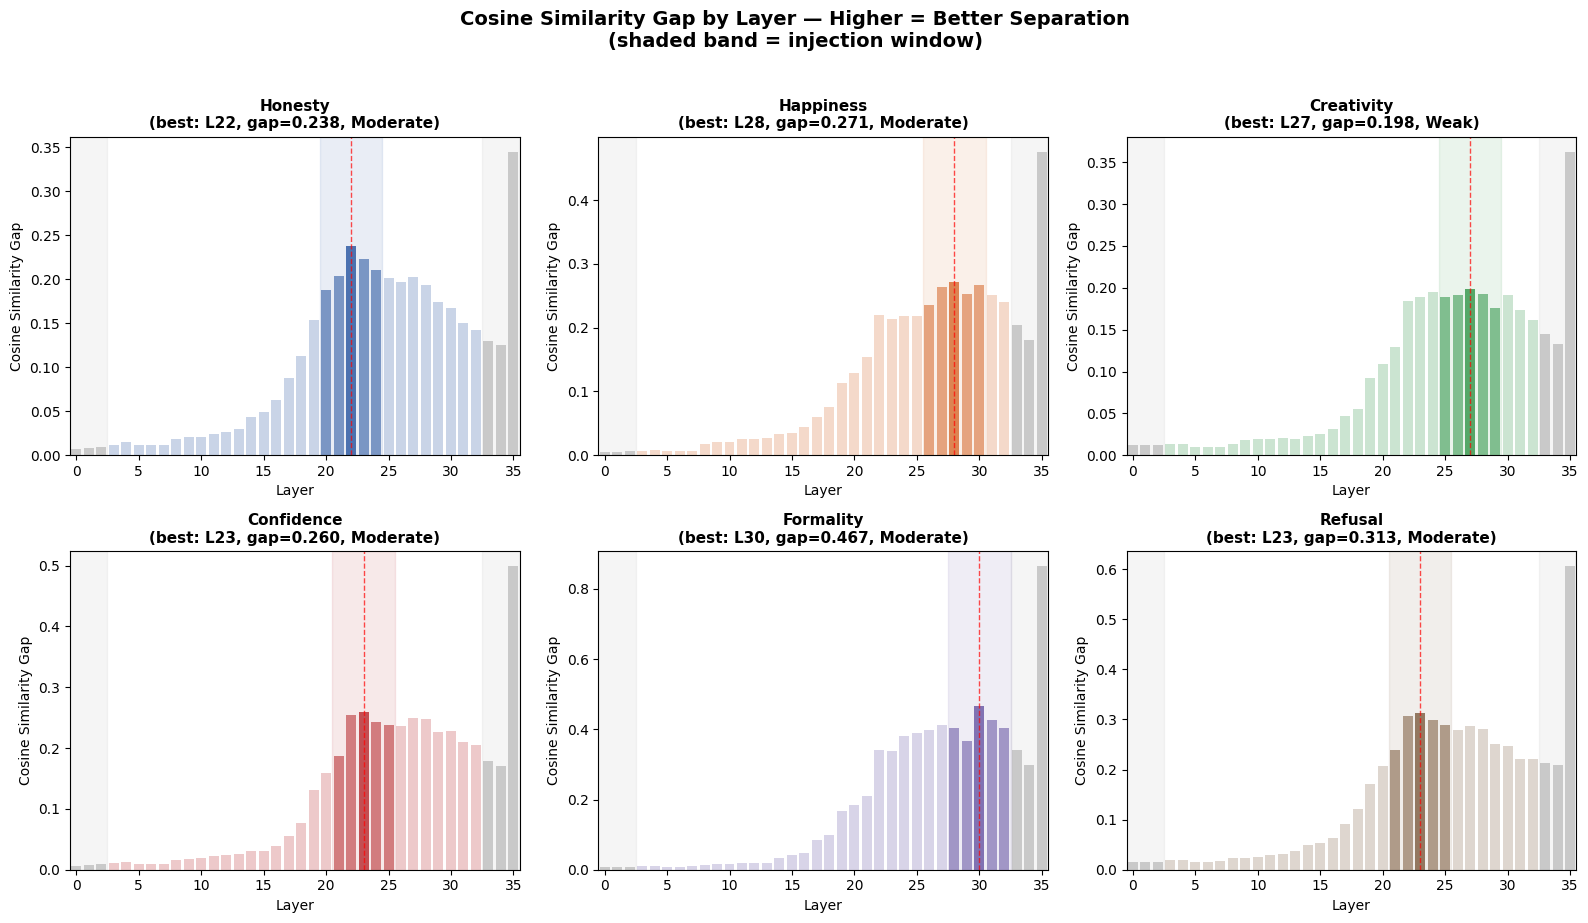

In [7]:
# ── Visualization: cosine gap per layer with injection window ──
n_concepts = len(CONCEPTS)
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

for idx, (concept, gaps) in enumerate(layer_gaps.items()):
    ax = axes[idx]
    best_l = best_layers[concept]
    inject_start = max(0, best_l - LAYER_SPREAD)
    inject_end = min(N_LAYERS_A, best_l + LAYER_SPREAD + 1)
    
    colors = []
    for l in range(N_LAYERS_A):
        if l == best_l:
            colors.append(palette[idx])
        elif inject_start <= l < inject_end:
            # Injection window — lighter but distinct
            colors.append(mcolors.to_rgba(palette[idx], alpha=0.7))
        elif l in valid_range:
            colors.append(mcolors.to_rgba(palette[idx], alpha=0.3))
        else:
            colors.append('#D0D0D0')  # grayed out edges
    
    ax.bar(range(N_LAYERS_A), gaps, color=colors, edgecolor='none')
    ax.axvline(best_l, color='red', linestyle='--', alpha=0.7, linewidth=1)
    
    # Shade injection window
    ax.axvspan(inject_start - 0.5, inject_end - 0.5, alpha=0.12, color=palette[idx], 
               label=f'Injection window')
    
    # Gap quality indicator
    gap_val = gaps[best_l]
    quality = "Strong" if gap_val > 0.5 else ("Moderate" if gap_val > 0.2 else "Weak")
    ax.set_title(f"{concept}\n(best: L{best_l}, gap={gap_val:.3f}, {quality})",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Layer")
    ax.set_ylabel("Cosine Similarity Gap")
    ax.set_xlim(-0.5, N_LAYERS_A - 0.5)
    
    # Shade the edge regions
    ax.axvspan(-0.5, EDGE_SKIP - 0.5, alpha=0.08, color='gray')
    ax.axvspan(N_LAYERS_A - EDGE_SKIP - 0.5, N_LAYERS_A - 0.5, alpha=0.08, color='gray')

plt.suptitle("Cosine Similarity Gap by Layer — Higher = Better Separation\n(shaded band = injection window)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Step 6 — Extract Final Steering Vectors

Now that we know the best layer for each concept, we extract the steering vector
at that specific layer:

$$\vec{v}_{\text{concept}} = \mathbb{E}[\vec{h}_{\text{positive}}] - \mathbb{E}[\vec{h}_{\text{negative}}]$$

In [8]:
# ── Extract steering vectors at the best layer per concept ──
steering_vectors = {}  # concept → {"vector": np.array, "layer": int, "norm": float}

print("🎯 Extracting raw steering vectors at best layers...")
raw_vectors = {}
for concept, best_l in best_layers.items():
    pos_mean = concept_activations[concept]["positive"][best_l].mean(axis=0)
    neg_mean = concept_activations[concept]["negative"][best_l].mean(axis=0)
    v = pos_mean - neg_mean
    raw_vectors[concept] = v

# ── Calibrate to source model's activation norms ──
# Instead of using arbitrary vector norms, measure actual activation magnitudes
print("\n📐 Probing source model activation norms for calibration...")
# Use the median best layer as representative
all_best = sorted(best_layers.values())
probe_layer = int(np.median(all_best))
source_act_norm, source_act_std = probe_activation_norms(
    nn_A, tok_A, list(alignment_prompts_raw), probe_layer, n_samples=30
)
print(f"   Typical activation norm at layer {probe_layer}: {source_act_norm:.2f} ± {source_act_std:.2f}")

# Scale each vector to NORM_FRACTION of the typical activation norm
SOURCE_BASE_NORM = source_act_norm * NORM_FRACTION
print(f"   Base injection norm: {SOURCE_BASE_NORM:.4f} ({NORM_FRACTION*100:.0f}% of activation norm)")

print("\n🎯 Scaling and saving steering vectors...")
for concept, best_l in best_layers.items():
    v = raw_vectors[concept]
    raw_norm = float(np.linalg.norm(v))
    v_unit = v / raw_norm
    v_scaled = v_unit * SOURCE_BASE_NORM
    
    steering_vectors[concept] = {
        "vector": v_scaled,
        "layer": best_l,
        "norm": float(np.linalg.norm(v_scaled)),
        "raw_norm": raw_norm,
        "direction": v_unit,  # Keep unit direction for later
    }
    print(f"   {concept:15s}  layer={best_l:2d}  raw_norm={raw_norm:.2f}  scaled_norm={np.linalg.norm(v_scaled):.4f}  shape={v_scaled.shape}")

# Free the large all-layers activation data
del concept_activations
cleanup()
print("\n✅ Steering vectors extracted and norm-calibrated, activation data freed")

🎯 Extracting raw steering vectors at best layers...

📐 Probing source model activation norms for calibration...


Probing norms:   0%|          | 0/30 [00:00<?, ?it/s]

   Typical activation norm at layer 25: 137.44 ± 8.62
   Base injection norm: 6.8719 (5% of activation norm)

🎯 Scaling and saving steering vectors...
   Honesty          layer=22  raw_norm=14.41  scaled_norm=6.8719  shape=(2560,)
   Happiness        layer=28  raw_norm=42.28  scaled_norm=6.8719  shape=(2560,)
   Creativity       layer=27  raw_norm=27.45  scaled_norm=6.8719  shape=(2560,)
   Confidence       layer=23  raw_norm=19.65  scaled_norm=6.8719  shape=(2560,)
   Formality        layer=30  raw_norm=109.90  scaled_norm=6.8719  shape=(2560,)
   Refusal          layer=23  raw_norm=23.64  scaled_norm=6.8719  shape=(2560,)

✅ Steering vectors extracted and norm-calibrated, activation data freed


---
## Step 7 — Validate on Source Model

Before translating, let's prove the vectors work on the source model itself.
For each concept we test:
- **+v** (add the vector): should push behavior toward the *positive* persona
- **−v** (subtract the vector): should push behavior toward the *negative* persona

Vectors are now **norm-calibrated**: the base vector is scaled to a small fraction
of the model's typical activation norm. Alpha acts as a multiplier on this base,
so α=1.0 is a gentle nudge and α=10+ is a strong push.

We start with a sweep of low alphas to find the sweet spot before causing degradation.

In [9]:
# ── Validate steering vectors on source model ──
test_prompts_src = [
    "Give me three tips for staying healthy.",
    "Write a short poem about the ocean.",
    "What are the pros and cons of remote work?",
]

print("=" * 80)
print("🧪 STEERING VECTOR VALIDATION — Source Model")
print(f"   {len(test_prompts_src)} test prompts, norm-calibrated injection")
print(f"   Base norm: {SOURCE_BASE_NORM:.4f} ({NORM_FRACTION*100:.0f}% of activation norm)")
print(f"   Alpha sweep: {ALPHAS}")
print("=" * 80)

for prompt_idx, test_prompt in enumerate(test_prompts_src):
    validation_html_parts = []
    validation_html_parts.append(f"<h2>📝 \"{test_prompt}\"</h2>")
    
    for concept, sv_data in steering_vectors.items():
        v = sv_data["vector"]
        best_l = sv_data["layer"]
        inject_layers = list(range(
            max(0, best_l - LAYER_SPREAD),
            min(N_LAYERS_A, best_l + LAYER_SPREAD + 1)
        ))
        pos_name, neg_name = CONCEPTS[concept]
        
        baseline = generate_with_multilayer_injection(raw_A, tok_A, test_prompt, inject_layers, v, 0.0)
        
        html = f"<h3>🔷 {concept}</h3>"
        html += f"<p><small>Layers: {inject_layers} | Personas: {pos_name} vs {neg_name}</small></p>"
        html += f"<p>{highlight_text(baseline, COLORS['baseline'], '⚪ Baseline')}</p>"
        
        for alpha in ALPHAS:
            if alpha == 0.0:
                continue
            positive = generate_with_multilayer_injection(raw_A, tok_A, test_prompt, inject_layers, v, alpha)
            negative = generate_with_multilayer_injection(raw_A, tok_A, test_prompt, inject_layers, -v, alpha)
            html += f"<p>{highlight_text(positive, COLORS['positive'], f'✅ +v (α={alpha})')}</p>"
            html += f"<p>{highlight_text(negative, COLORS['negative'], f'❌ −v (α={alpha})')}</p>"
        
        html += "<hr>"
        validation_html_parts.append(html)
    
    validation_html_parts.append("<br>")
    display(HTML("".join(validation_html_parts)))

🧪 STEERING VECTOR VALIDATION — Source Model
   3 test prompts, norm-calibrated injection
   Base norm: 6.8719 (5% of activation norm)
   Alpha sweep: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


---
## Step 8 — Extract Alignment Activations & Unload Source

Before unloading the source model, we run the Alpaca alignment prompts through it
and save the activations. These will be paired with the target model's activations
to learn the translation matrix.

We extract at the **median** of all best layers — a representative mid-to-late layer.

In [10]:
# ── Pick the alignment layer (median of all best layers) ──
all_best = sorted(best_layers.values())
SOURCE_ALIGN_LAYER = int(np.median(all_best))
print(f"📊 Alignment layer for source model: {SOURCE_ALIGN_LAYER}")
print(f"   (median of best layers: {all_best})")

print(f"\n📊 Extracting alignment activations from source model...")
X_align = extract_single_layer(nn_A, tok_A, alignment_prompts_raw, SOURCE_ALIGN_LAYER, "Alignment")
print(f"   ✅ Shape: {X_align.shape}")

# ── Free GPU memory ──
print("🧹 Unloading source model...")
del raw_A, nn_A, tok_A
cleanup()
print(f"   VRAM in use: {torch.cuda.memory_allocated()/1e9:.2f} GB")


📊 Alignment layer for source model: 25
   (median of best layers: [22, 23, 23, 27, 28, 30])

📊 Extracting alignment activations from source model...


Alignment:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ Shape: (200, 2560)
🧹 Unloading source model...
   VRAM in use: 0.01 GB


---
## Step 9 — Load Target Model & Extract Alignment Activations

Now we load the target model and run the same Alpaca prompts through it.
This gives us paired activations — same prompts, different models.

In [11]:
print(f"🧠 Loading target model: {TARGET_MODEL}")
tok_B = AutoTokenizer.from_pretrained(TARGET_MODEL, trust_remote_code=True)
raw_B = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL, torch_dtype=torch.float16, device_map=DEVICE, trust_remote_code=True,
)
if tok_B.pad_token is None:
    tok_B.pad_token = tok_B.eos_token
nn_B = LanguageModel(raw_B, tokenizer=tok_B)

N_LAYERS_B = len(raw_B.model.layers)
HIDDEN_B = raw_B.config.hidden_size

# ── Match relative depth from source model ──
# The source alignment layer was at SOURCE_ALIGN_LAYER / N_LAYERS_A depth.
# We pick the equivalent relative position in the target model.
source_depth_ratio = SOURCE_ALIGN_LAYER / N_LAYERS_A
TARGET_ALIGN_LAYER = int(N_LAYERS_B * source_depth_ratio)
TARGET_ALIGN_LAYER = max(1, min(TARGET_ALIGN_LAYER, N_LAYERS_B - 2))  # safety clamp

# Define injection layers around the target alignment layer
target_inject_layers = list(range(
    max(0, TARGET_ALIGN_LAYER - LAYER_SPREAD),
    min(N_LAYERS_B, TARGET_ALIGN_LAYER + LAYER_SPREAD + 1)
))

print(f"   ✅ {N_LAYERS_B} layers, hidden_size={HIDDEN_B}")
print(f"   📝 Chat template: {repr(format_chat(tok_B, None, 'Hello!')[:80])}…")
print(f"   📊 Source alignment depth: {source_depth_ratio:.2%} (layer {SOURCE_ALIGN_LAYER}/{N_LAYERS_A})")
print(f"   📊 Target alignment layer: {TARGET_ALIGN_LAYER} ({TARGET_ALIGN_LAYER/N_LAYERS_B:.2%} depth)")
print(f"   📊 Injection layers: {target_inject_layers}")

print(f"\n📊 Extracting alignment activations from target model...")
Y_align = extract_single_layer(nn_B, tok_B, alignment_prompts_raw, TARGET_ALIGN_LAYER, "Alignment")
print(f"   ✅ Shape: {Y_align.shape}")

🧠 Loading target model: LiquidAI/LFM2.5-1.2B-Instruct


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   ✅ 16 layers, hidden_size=2048
   📝 Chat template: '<|startoftext|><|im_start|>user\nHello!<|im_end|>\n<|im_start|>assistant\n'…
   📊 Source alignment depth: 69.44% (layer 25/36)
   📊 Target alignment layer: 11 (68.75% depth)
   📊 Injection layers: [9, 10, 11, 12, 13]

📊 Extracting alignment activations from target model...


Alignment:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ Shape: (200, 2048)


---
## Step 10 — Compute (or Load) the Translation Matrix

Set `LOAD_EXISTING = True` to load a previously saved translation matrix,
or `False` to compute a new one.

The matrix maps source activations → target activations using
cross-dimensional Orthogonal Procrustes.

In [12]:
LOAD_EXISTING = False  # ← Set to True to load a saved matrix

if LOAD_EXISTING and os.path.exists(TRANSLATION_MATRIX_PATH):
    print(f"📂 Loading translation matrix from {TRANSLATION_MATRIX_PATH}")
    data = np.load(TRANSLATION_MATRIX_PATH)
    T = data["T"]
    mean_cos = float(data["mean_cos"])
    print(f"   ✅ Shape: {T.shape}, quality: {mean_cos:.3f}")
else:
    print("🔧 Computing translation matrix (cross-dimensional Procrustes)...")
    
    # Center the activations
    X_c = X_align - X_align.mean(axis=0)
    Y_c = Y_align - Y_align.mean(axis=0)
    
    # SVD of each centered matrix
    k = min(X_c.shape[0], X_c.shape[1], Y_c.shape[1])
    U_x, S_x, Vt_x = np.linalg.svd(X_c, full_matrices=False)
    U_y, S_y, Vt_y = np.linalg.svd(Y_c, full_matrices=False)
    
    # Project into shared subspace
    X_proj = U_x[:, :k] * S_x[:k]
    Y_proj = U_y[:, :k] * S_y[:k]
    
    # Optimal rotation in the shared space
    R_shared, _ = orthogonal_procrustes(X_proj, Y_proj)
    
    # Full translation matrix: (dim_A × dim_B)
    T = Vt_x[:k, :].T @ R_shared @ Vt_y[:k, :]
    
    # Quality check
    Y_pred = X_c @ T
    cos_sims = [cosine_similarity(Y_c[i:i+1], Y_pred[i:i+1])[0, 0] for i in range(len(Y_c))]
    mean_cos = float(np.mean(cos_sims))
    
    print(f"   ✅ Translation matrix shape: {T.shape}")
    print(f"   📐 Mean cosine similarity (predicted vs actual): {mean_cos:.3f}")
    print(f"      (> 0.7 is good, > 0.9 is excellent)")
    
    # Save for future use
    np.savez(TRANSLATION_MATRIX_PATH, T=T, mean_cos=np.array(mean_cos))
    print(f"   💾 Saved to {TRANSLATION_MATRIX_PATH}")


🔧 Computing translation matrix (cross-dimensional Procrustes)...
   ✅ Translation matrix shape: (2560, 2048)
   📐 Mean cosine similarity (predicted vs actual): 0.941
      (> 0.7 is good, > 0.9 is excellent)
   💾 Saved to translation_matrix.npz


---
## Step 11 — Translate & Inject All Concepts

For each concept, we:
1. Translate the steering vector's **unit direction** into the target model's space
2. **Calibrate norm**: probe the target model's actual activation norms and scale
   the translated vector to `NORM_FRACTION` of that — matching how we did it on source
3. Inject at multiple layers (target layer ± LAYER_SPREAD)
4. Test with increasing injection strength (α)

The translation matrix was built from **general-purpose** data (Alpaca), yet we're
using it to transfer **behavioral** concepts — this is the universal translator at work!

In [13]:
print("=" * 80)
print("🌉 TRANSLATING STEERING VECTORS to Target Architecture")
print("=" * 80)

# ── Probe target model's activation norms for calibration ──
print("\n📐 Probing target model activation norms...")
target_act_norm, target_act_std = probe_activation_norms(
    nn_B, tok_B, list(alignment_prompts_raw), TARGET_ALIGN_LAYER, n_samples=30
)
print(f"   Typical activation norm at layer {TARGET_ALIGN_LAYER}: {target_act_norm:.2f} ± {target_act_std:.2f}")

TARGET_BASE_NORM = target_act_norm * NORM_FRACTION
print(f"   Base injection norm: {TARGET_BASE_NORM:.4f} ({NORM_FRACTION*100:.0f}% of activation norm)")

# ── Translate and rescale ──
translated_vectors = {}
print(f"\n🎯 Translating and scaling vectors...")
for concept, sv_data in steering_vectors.items():
    # Translate the UNIT DIRECTION (not the scaled vector)
    v_dir = sv_data["direction"]
    v_translated = v_dir @ T
    
    # Normalize in target space and scale to calibrated norm
    v_translated_unit = v_translated / np.linalg.norm(v_translated)
    v_scaled = v_translated_unit * TARGET_BASE_NORM
    translated_vectors[concept] = v_scaled
    
    print(f"   {concept:15s}  translated_norm={np.linalg.norm(v_scaled):.4f}  "
          f"(= {NORM_FRACTION*100:.0f}% of {target_act_norm:.2f})")

🌉 TRANSLATING STEERING VECTORS to Target Architecture

📐 Probing target model activation norms...


Probing norms:   0%|          | 0/30 [00:00<?, ?it/s]

   Typical activation norm at layer 11: 1.12 ± 0.07
   Base injection norm: 0.0559 (5% of activation norm)

🎯 Translating and scaling vectors...
   Honesty          translated_norm=0.0559  (= 5% of 1.12)
   Happiness        translated_norm=0.0559  (= 5% of 1.12)
   Creativity       translated_norm=0.0559  (= 5% of 1.12)
   Confidence       translated_norm=0.0559  (= 5% of 1.12)
   Formality        translated_norm=0.0559  (= 5% of 1.12)
   Refusal          translated_norm=0.0559  (= 5% of 1.12)


In [14]:
# ── Validate target model with transferred vectors ──
test_prompts = [
    "Give me three tips for staying healthy.",
    "Explain how photosynthesis works.",
    "Write a short poem about the ocean.",
    "What are the pros and cons of remote work?",
    "How do I make scrambled eggs?",
    "Describe the difference between a virus and a bacterium.",
]

print("=" * 80)
print("🧪 CROSS-ARCHITECTURE INJECTION TEST — Target Model")
print(f"   Target model: {TARGET_MODEL}")
print(f"   Injection layers: {target_inject_layers}")
print(f"   Base norm: {TARGET_BASE_NORM:.4f} ({NORM_FRACTION*100:.0f}% of activation norm)")
print(f"   Alpha sweep: {ALPHAS}")
print(f"   Test prompts: {len(test_prompts)}")
print("=" * 80)

for prompt in test_prompts:
    all_html_parts = []
    all_html_parts.append(f"<h2>📝 \"{prompt}\"</h2>")
    
    for concept in CONCEPTS:
        pos_name, neg_name = CONCEPTS[concept]
        v = translated_vectors[concept]
        
        html = f"<h3>🔷 {concept}</h3>"
        
        # Calculate baseline once
        baseline_text = generate_with_multilayer_injection(
            raw_B, tok_B, prompt, target_inject_layers,
            np.zeros_like(v), 0.0
        )
        html += f"<p><small>Layers: {target_inject_layers} | Personas: {pos_name} vs {neg_name} | "
        html += f"Base norm: {np.linalg.norm(v):.4f}</small></p>"
        html += f"<p>{highlight_text(baseline_text, COLORS['baseline'], '⚪ Baseline')}</p>"
        
        for alpha in ALPHAS:
            if alpha == 0.0: continue
            
            pos_text = generate_with_multilayer_injection(
                raw_B, tok_B, prompt, target_inject_layers, v, alpha
            )
            neg_text = generate_with_multilayer_injection(
                raw_B, tok_B, prompt, target_inject_layers, -v, alpha
            )
            
            effective_norm = np.linalg.norm(v) * alpha
            html += f"<p>{highlight_text(pos_text, COLORS['positive'], f'✅ +v (α={alpha}, eff_norm={effective_norm:.2f})')}</p>"
            html += f"<p>{highlight_text(neg_text, COLORS['negative'], f'❌ −v (α={alpha}, eff_norm={effective_norm:.2f})')}</p>"
            
        html += "<hr>"
        all_html_parts.append(html)
    
    all_html_parts.append("<br>")
    display(HTML("".join(all_html_parts)))

🧪 CROSS-ARCHITECTURE INJECTION TEST — Target Model
   Target model: LiquidAI/LFM2.5-1.2B-Instruct
   Injection layers: [9, 10, 11, 12, 13]
   Base norm: 0.0559 (5% of activation norm)
   Alpha sweep: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
   Test prompts: 6
